# Generic fed-batch growth: a forward-simulation homework example

This companion to `generic_batch` uses the **same biological model and initial conditions**, with one nutrient-feed pulse at 3 h.
It is an idealized capability demonstration, not a calibrated biological model or a continuous-feed process.
Run the seven steps in order with **Shift+Enter** in the demonstrator's Python 3.11 environment.

**Inputs:** `inputs/case.json`, `inputs/mechanism.json`, and `inputs/thermo.json`.
**Outputs:** `outputs/trajectories.csv`, `outputs/trajectories.png`, and `outputs/summary.json`.
The default run checks and plots results without writing files. Step 7 optionally regenerates the supplied outputs.
No runner script, parameter estimation, or experiment design is used.

### Model and independent solution

The initial 1 L liquid contains 10 mmol of hypothetical nutrient and 0.1 gDW biomass.
One pathway maximizes growth, with $a=10$ mol/kgDW and $q_{\max}=2$ mol/(kgDW h):

\[
\max_{v\ge0}v,\quad av\le q_{\max},\quad
\dot n=-avB,\quad\dot B=vB,\quad\mu=q_{\max}/a=0.2\;\mathrm{h}^{-1}.
\]

A feed pulse adds nutrient and water but no cells; biomass **amount** is continuous and its concentration is diluted.
Before depletion, with $I=0$ before the feed and $I=1$ after it,

\[
B(t)=B_0e^{\mu t},\qquad n(t)=n_0+I\Delta n-a[B(t)-B_0].
\]

**Native feed convention:** `volume_l` supplies carrier volume; nutrient mass is added separately from
`concentrations_mmol_l * volume_l`. Here 0.1 L of carrier at 50 mmol/L-carrier adds 5 mmol nutrient.
At 100 g/mol this adds 0.0005 kg nutrient plus 0.1 kg water, so the total liquid-volume jump at the
assumed density is **0.1005 L**, not exactly 0.1 L. These fields do not prescribe a final mixed-solution volume.
Feed `time` uses the reporting-step unit, hours in this case.

The idealized yield is 1 gDW per g nutrient. **Liquid mass + dry biomass − cumulative feed mass** is conserved.
Liquid volume is derived from current liquid mass at constant density; biomass volume is neglected.
The table retains both pre-feed and post-feed rows at 3 h, identified by `segment_index` and `feed_applied`.

Maintenance, death, respiration, gas transfer, product formation, energy limitation, and finite feed duration
are omitted. Property values are illustrative. Mass closure does not establish elemental or energetic closure.
The supplied six-hour run stays before depletion on both sides of the event.

## Step 1 — Imports and input locations

In [1]:
# STEP 1: Imports and input locations
# Run this cell first with Shift+Enter in the demonstrator's Python environment.
# If this notebook is outside the checkout, set repo_root explicitly. To use a
# copied example, change example_dir below. No runner scripts are imported.
from pathlib import Path
import csv
import hashlib
import json
import platform
import sys
import numpy as np
import scipy
import matplotlib.pyplot as plt

repo_root = next((path for path in (Path.cwd(), *Path.cwd().parents)
                  if (path / "PharmaPy").is_dir()), None)
if repo_root is None:
    raise ValueError("Set repo_root to your PharmaPy checkout before running this cell")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from PharmaPy.Bioreactors import build_bioreactor

example_dir = repo_root / "examples/bioreactors/generic_fed_batch"
input_dir = example_dir / "inputs"
WRITE_ARTIFACTS = False
EXPORT_DIR = example_dir / "outputs"

## Step 2 — Load and edit the three inputs

In [2]:
# STEP 2: Load and edit model, operation, and feed settings
# Run after editing any JSON file, then rerun every following step. Initial
# nutrient is mol, biomass kgDW, and feed concentration mmol/L of carrier.
# This notebook verifies one pulse strictly inside the simulation interval.
# Keep the one-nutrient pathway and constant-density assumptions for the checks.
case = json.loads((input_dir / "case.json").read_text())
config = json.loads((input_dir / "mechanism.json").read_text())
thermo_path = input_dir / "thermo.json"

# config["model"]["parameters"]["nutrient_uptake_max"] = 1.0
# config["recipes"]["fed_batch"][0]["volume_l"] = 0.05
# config["recipes"]["fed_batch"][0]["time"] = 2.0
# config["recipes"]["fed_batch"][0]["concentrations_mmol_l"]["nutrient"] = 100.0
# Use numerical hours in these settings; changing time units requires adapting the checks.

## Step 3 — Construct and run the native reactor

In [3]:
# STEP 3: Construct and run the native fed-batch reactor
# Run to build a fresh SemiBatchReactor. The assembly runs solve_unit to the
# feed, updates the inventories, and continues through solve_unit again.
# histories preserves both segments; unit.result alone is only the final one.
events = config["recipes"][case["recipe"]["name"]]
assert len(events) == 1 and events[0]["event_type"] == "feed"
assert case["numerics"]["step"]["unit"] == case["operation"]["runtime"]["unit"] == "h"
feed = events[0]
feed_time_h = float(feed["time"])
assert 0.0 < feed_time_h < case["operation"]["runtime"]["value"]
assert set(feed["concentrations_mmol_l"]) == {"nutrient"}
assembly = build_bioreactor(case, config, thermo_path)
unit = assembly.unit
histories = assembly.solve(verbose=False)
assert len(histories) == 2
print("Native reactor:", type(unit).__name__)
print("Backend:", type(unit.integrator).__name__)
print("Recorded segments:", len(histories))

Native reactor: SemiBatchReactor
Backend: SciPyBackend
Recorded segments: 2


## Step 4 — Extract inventories and concentrations

In [4]:
# STEP 4: Extract both sides of the feed event with explicit units
# Run to create the trajectory table. Keep the duplicate feed time: segment 0
# ends before feeding and segment 1 starts after feeding. Concentrations use
# each row's liquid volume; biomass amount must not jump when carrier is added.
nutrient_index = list(assembly.phase.name_species).index("nutrient")
water_index = list(assembly.phase.name_species).index("water")
molecular_weight = float(assembly.phase.mw[nutrient_index])
time_h = np.concatenate([np.asarray(result.time) / 3600.0 for result in histories])
mass_kg = np.concatenate([np.asarray(result.mass_j_liquid0) for result in histories])
biomass_kg = np.concatenate([np.asarray(result.biomass_kg_liquid0).reshape(-1)
                             for result in histories])
segment_index = np.concatenate([np.full(len(result.time), index, dtype=int)
                                for index, result in enumerate(histories)])
feed_applied = segment_index.copy()
nutrient_mol = mass_kg[:, nutrient_index] * 1000.0 / molecular_weight
liquid_mass_kg = mass_kg.sum(axis=1)
density = case["operation"]["carrier_density_kg_l"]
volume_l = liquid_mass_kg / density
rows = [dict(time_h=float(t), segment_index=int(segment), feed_applied=int(applied),
             nutrient_mmol=float(n * 1000.0), biomass_gdw=float(b * 1000.0),
             liquid_volume_l=float(volume), nutrient_mmol_l=float(n * 1000.0 / volume),
             biomass_gdw_l=float(b * 1000.0 / volume),
             liquid_plus_biomass_kg=float(mass + b))
        for t, segment, applied, n, b, volume, mass in zip(
            time_h, segment_index, feed_applied, nutrient_mol, biomass_kg,
            volume_l, liquid_mass_kg)]
print("Feed boundary rows:", [row for row in rows if np.isclose(row["time_h"], feed_time_h)])
print("Final row:", rows[-1])

Feed boundary rows: [{'time_h': 3.0, 'segment_index': 0, 'feed_applied': 0, 'nutrient_mmol': 9.17788106224849, 'biomass_gdw': 0.18221189377515115, 'liquid_volume_l': 0.9999177881062249, 'nutrient_mmol_l': 9.178635655267982, 'biomass_gdw_l': 0.18222687499164095, 'liquid_plus_biomass_kg': 1.0001}, {'time_h': 3.0, 'segment_index': 1, 'feed_applied': 1, 'nutrient_mmol': 14.177881062248492, 'biomass_gdw': 0.18221189377515115, 'liquid_volume_l': 1.100417788106225, 'nutrient_mmol_l': 12.884089311794986, 'biomass_gdw_l': 0.1655842860271557, 'liquid_plus_biomass_kg': 1.1006}]
Final row: {'time_h': 6.0, 'segment_index': 1, 'feed_applied': 1, 'nutrient_mmol': 12.679882633644375, 'biomass_gdw': 0.33201173663556255, 'liquid_volume_l': 1.1002679882633644, 'nutrient_mmol_l': 11.524358400772876, 'biomass_gdw_l': 0.30175533613370104, 'liquid_plus_biomass_kg': 1.1006}


## Step 5 — Check the analytical solution and mass accounting

In [5]:
# STEP 5: Check the piecewise solution, feed jump, and mass accounting
# Run to compare all rows, including both event sides, with an independent
# formula. A constant specific uptake cap leaves biomass amount growing at the
# same rate after feeding, while concentration is diluted. This formula assumes
# nutrient remains available; shorten an edited run if that assumption fails.
model = config["model"]
assert model["state_ids"] == ["nutrient"] and model["pathway_ids"] == ["assimilation"]
assert model["growth_coefficients"] == [1.0] and config["flux_time_unit"] == "1/h"
assert config["transport"] is None and model["uptake_constraints"][0]["type"] == "constant"
a = -float(model["exchange_matrix"][0][0])
q_max = float(model["parameters"]["nutrient_uptake_max"])
assert a > 0.0 and q_max > 0.0
np.testing.assert_allclose(a * molecular_weight / 1000.0, 1.0, rtol=0, atol=1e-12)
properties = json.loads(thermo_path.read_text())
for species in properties.values():
    np.testing.assert_allclose(species["rho_liq"], density * 1000.0)
mu = q_max / a
b0 = float(config["state"]["biomass_kg"])
n0 = float(config["state"]["species_mol"]["nutrient"])
feed_nutrient_mol = feed["volume_l"] * feed["concentrations_mmol_l"]["nutrient"] / 1000.0
feed_water_kg = feed["volume_l"] * density
feed_mass_kg = feed_water_kg + feed_nutrient_mol * molecular_weight / 1000.0
biomass_exact = b0 * np.exp(mu * time_h)
nutrient_exact = n0 + feed_applied * feed_nutrient_mol - a * (biomass_exact - b0)
if np.any(nutrient_exact <= 0.0):
    raise ValueError("Analytic check assumes available nutrient: shorten the run or derive a depletion solution")
assert np.isfinite(mass_kg).all() and np.isfinite(biomass_kg).all()
assert mass_kg.min() >= -1e-12 and biomass_kg.min() >= 0.0
np.testing.assert_allclose(biomass_kg, biomass_exact, rtol=1e-6, atol=1e-10)
np.testing.assert_allclose(nutrient_mol, nutrient_exact, rtol=1e-6, atol=1e-9)
total_mass = liquid_mass_kg + biomass_kg
initial_total = case["operation"]["initial_mass_kg"] + b0
mass_error = total_mass - feed_applied * feed_mass_kg - initial_total
np.testing.assert_allclose(mass_error, 0.0, rtol=0, atol=1e-10)
np.testing.assert_allclose(nutrient_mol + a * biomass_kg - feed_applied * feed_nutrient_mol,
                           n0 + a * b0, rtol=0, atol=1e-9)
np.testing.assert_allclose(mass_kg[:, water_index],
                           mass_kg[0, water_index] + feed_applied * feed_water_kg,
                           rtol=0, atol=1e-10)
pre = len(histories[0].time) - 1
post = pre + 1
np.testing.assert_allclose(time_h[[pre, post]], feed_time_h, rtol=0, atol=1e-12)
np.testing.assert_allclose(biomass_kg[post], biomass_kg[pre], rtol=0, atol=1e-12)
np.testing.assert_allclose(nutrient_mol[post] - nutrient_mol[pre], feed_nutrient_mol,
                           rtol=0, atol=1e-12)
np.testing.assert_allclose(volume_l[post] - volume_l[pre], feed_mass_kg / density,
                           rtol=0, atol=1e-12)
np.testing.assert_allclose(rows[post]["biomass_gdw_l"] / rows[pre]["biomass_gdw_l"],
                           volume_l[pre] / volume_l[post], rtol=1e-10)
summary = {
    "status": "PASS", "native_unit": type(unit).__name__,
    "backend": type(unit.integrator).__name__, "recorded_rows": len(rows),
    "growth_rate_per_h": mu, "final": rows[-1],
    "feed": {"time_h": feed_time_h, "nutrient_added_mmol": feed_nutrient_mol * 1000.0,
             "total_mass_added_kg": feed_mass_kg,
             "pre": rows[pre], "post": rows[post]},
    "maximum_biomass_relative_error": float(np.max(abs(biomass_kg / biomass_exact - 1.0))),
    "maximum_nutrient_absolute_error_mol": float(np.max(abs(nutrient_mol - nutrient_exact))),
    "maximum_total_mass_error_kg": float(np.max(abs(mass_error))),
    "checks": {"analytical_solution": True, "nonnegative_inventories": True,
               "feed_corrected_mass_conservation": True, "nutrient_biomass_balance": True,
               "water_accounting": True, "feed_jump": True, "biomass_continuity": True,
               "concentration_dilution": True},
    "acceptance": {"analytical_rtol": 1e-6, "biomass_atol_kgdw": 1e-10,
                   "nutrient_atol_mol": 1e-9, "total_mass_atol_kg": 1e-10},
    "effective_inputs": {"case": case, "mechanism": config},
    "thermo_sha256": hashlib.sha256(thermo_path.read_bytes()).hexdigest(),
    "environment": {"python": platform.python_version(), "numpy": np.__version__,
                    "scipy": scipy.__version__},
    "evidence_limit": "Analytic verification of an idealized pulse-fed model; not experimental validation."
}
print(json.dumps({key: summary[key] for key in ("status", "growth_rate_per_h", "final",
                 "maximum_biomass_relative_error", "maximum_total_mass_error_kg")}, indent=2))

{
  "status": "PASS",
  "growth_rate_per_h": 0.2,
  "final": {
    "time_h": 6.0,
    "segment_index": 1,
    "feed_applied": 1,
    "nutrient_mmol": 12.679882633644375,
    "biomass_gdw": 0.33201173663556255,
    "liquid_volume_l": 1.1002679882633644,
    "nutrient_mmol_l": 11.524358400772876,
    "biomass_gdw_l": 0.30175533613370104,
    "liquid_plus_biomass_kg": 1.1006
  },
  "maximum_biomass_relative_error": 1.3361549822121788e-07,
  "maximum_total_mass_error_kg": 2.220446049250313e-16
}


## Step 6 — Plot the simulation and the independent solution

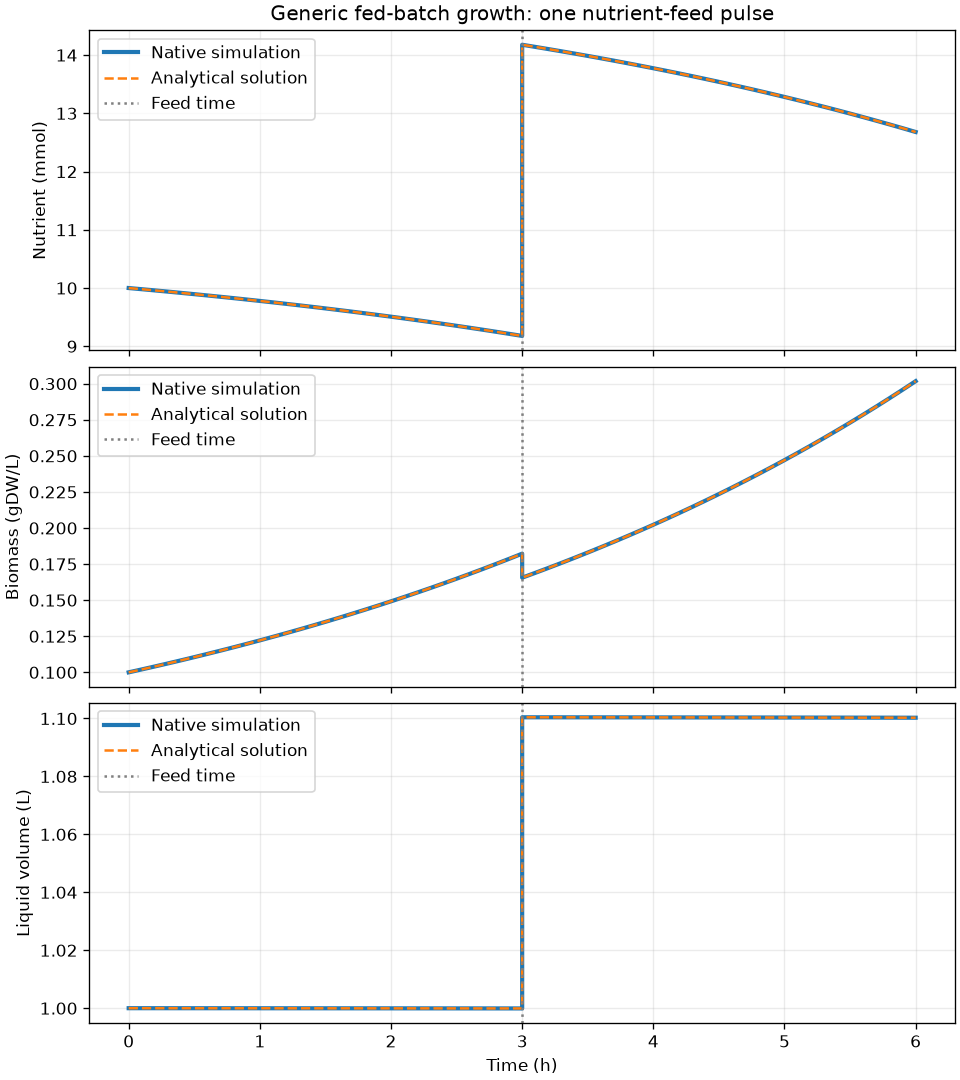

In [6]:
# STEP 6: Plot the numerical and analytical trajectories across feeding
# Run to display the figure. Duplicate event times show the actual jump.
# Biomass amount is continuous, but its concentration drops as volume increases.
# Both exact concentration and volume below use the independent mass balance.
volume_exact_l = (initial_total + feed_applied * feed_mass_kg - biomass_exact) / density
figure, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True, constrained_layout=True)
axes[0].plot(time_h, nutrient_mol * 1000.0, label="Native simulation", linewidth=2.5)
axes[0].plot(time_h, nutrient_exact * 1000.0, "--", label="Analytical solution")
axes[0].set(ylabel="Nutrient (mmol)", title="Generic fed-batch growth: one nutrient-feed pulse")
axes[1].plot(time_h, biomass_kg * 1000.0 / volume_l, label="Native simulation", linewidth=2.5)
axes[1].plot(time_h, biomass_exact * 1000.0 / volume_exact_l, "--", label="Analytical solution")
axes[1].set(ylabel="Biomass (gDW/L)")
axes[2].plot(time_h, volume_l, label="Native simulation", linewidth=2.5)
axes[2].plot(time_h, volume_exact_l, "--", label="Analytical solution")
axes[2].set(xlabel="Time (h)", ylabel="Liquid volume (L)")
for axis in axes:
    axis.axvline(feed_time_h, color="gray", linestyle=":", label="Feed time")
    axis.grid(alpha=0.25)
    axis.legend()
figure

## Step 7 — Optionally save this run

In [7]:
# STEP 7: Export results only when requested
# Set WRITE_ARTIFACTS=True in Step 1 and rerun the notebook to regenerate outputs.
# Set EXPORT_DIR to a different folder to retain the supplied demonstration.
# The summary records effective input dictionaries, properties checksum,
# package versions, numerical checks, and units alongside the trajectory CSV.
if WRITE_ARTIFACTS:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    with (EXPORT_DIR / "trajectories.csv").open("w", newline="") as stream:
        writer = csv.DictWriter(stream, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)
    (EXPORT_DIR / "summary.json").write_text(json.dumps(summary, indent=2) + "\n")
    figure.savefig(EXPORT_DIR / "trajectories.png", dpi=160)
    print("Saved outputs to:", EXPORT_DIR)
else:
    print("No files written. Set WRITE_ARTIFACTS=True to export this run.")

No files written. Set WRITE_ARTIFACTS=True to export this run.


## Suggested homework variations

1. Halve the feed volume. Predict nutrient addition, volume jump, and biomass-concentration dilution.
2. Double the nutrient concentration of the feed. Explain why biomass growth rate remains unchanged while nutrient is available under this constant-uptake law.
3. Move the feed to 2 h. Check that the output table preserves both sides of the new event time.
4. Halve the uptake cap and compare biomass amount with the batch example at the same cap.

Edit inputs, not library code. This notebook assumes one pulse, constant density, and no depletion.
For multiple pulses, continuous feeds, or nutrient-dependent growth, adapt the verification equations too.